In [59]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os, corner
from datetime import datetime
import tensorflow_probability as tfp
tfd = tfp.distributions

class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self, PROGRESS_EPOCH=50):
        self.PROGRESS_EPOCH = PROGRESS_EPOCH
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.PROGRESS_EPOCH == 0:
            print(f"{datetime.now().strftime('%H:%M:%S')}, epoch {epoch}: ", end="")
            for key, val in logs.items():
                print(f"{key}: {val:.3f}", end= "\t")
            print()

tf.config.list_physical_devices('GPU')

[]

In [24]:
df = pd.read_csv('../camels_info/camels_parameters.csv')

out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()

if "LH_603" in sim_names:
    sim_names.remove("LH_603")
    
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [25]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /  # pylint: disable=g-long-lambda
                           tf.cast(train_split, dtype=tf.float32))

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)


In [27]:
# rough parameters, cannot use the best optuna due to different input shape
# use padding same
best_params = {'n_conv_layers': 3, 'n_dense_layers': 2, 'log2(n_conv_units_l0)': 1, 'n_conv_kernel_l0': 3, 
               'log2(n_conv_units_l1)': 4, 'n_conv_kernel_l1': 2, 'log2(n_conv_units_l2)': 1, 
               'n_conv_kernel_l2': 2, 'log2(n_dense_units_l0)': 5, 'log2(n_dense_units_l1)': 7}

def get_tf_model(input_shape):
    n_conv_layers = best_params['n_conv_layers']
    n_dense_layers = best_params['n_dense_layers']

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))
    for i in range(n_conv_layers):
        num_hidden = 2 ** best_params[f'log2(n_conv_units_l{i})']
        kernel = best_params[f'n_conv_kernel_l{i}']
        model.add(tfp.layers.Convolution2DFlipout(num_hidden, kernel_size=(kernel, kernel),
                      kernel_divergence_fn=kl_divergence_function, activation=tf.nn.tanh, padding="same"))
        model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(tf.keras.layers.Flatten())

    for i in range(n_dense_layers):
        num_hidden = 2 ** best_params[f'log2(n_dense_units_l{i})']
        model.add(tfp.layers.DenseFlipout(num_hidden, activation=tf.nn.tanh,
              kernel_divergence_fn=kl_divergence_function))

    model.add(tf.keras.layers.Dense(tfp.layers.MultivariateNormalTriL.params_size(6)))
    model.add(tfp.layers.MultivariateNormalTriL(6))

    def negloglik(y_true, y_pred):
        return -tf.reduce_mean(y_pred.log_prob(y_true))

    optimizer=tf.keras.optimizers.Adadelta(learning_rate=0.2, rho=0.98)
    model.compile(optimizer, loss=negloglik, # tf.keras.losses.LogCosh(), # ['mse'], 
                  metrics=['mae', 'mse'], experimental_run_tf_function=False)
    model.summary()
    
    return model

In [28]:
inds, Zs = np.array(list(redshifts.keys())), np.array(list(redshifts.values()))

train_x_zless1, val_x_zless1, test_x_zless1 = train_x[:, Zs<1], val_x[:, Zs<1], test_x[:, Zs<1]
print(train_x_zless1.shape, val_x_zless1.shape, test_x_zless1.shape)

train_x_z_1_2, val_x_z_1_2, test_x_z_1_2 = train_x[:, np.logical_and(Zs>1, Zs<2)], \
                            val_x[:, np.logical_and(Zs>1, Zs<2)], test_x[:, np.logical_and(Zs>1, Zs<2)]
print(train_x_z_1_2.shape, val_x_z_1_2.shape, test_x_z_1_2.shape)

train_x_zover2, val_x_zover2, test_x_zover2 = train_x[:, Zs>2], val_x[:, Zs>2], test_x[:, Zs>2]
print(train_x_zover2.shape, val_x_zover2.shape, test_x_zover2.shape)

(849, 15, 22) (100, 15, 22) (50, 15, 22)
(849, 8, 22) (100, 8, 22) (50, 8, 22)
(849, 11, 22) (100, 11, 22) (50, 11, 22)


In [29]:
model_zless1, model_z_1_2, model_zover2, full_model = get_tf_model((15, 22, 1)), \
                        get_tf_model((8, 22, 1)), get_tf_model((11, 22, 1)), get_tf_model((34, 22, 1))

/global/homes/s/shubh/.conda/envs/simtim/lib/python3.9/site-packages/tensorflow_probability/python/layers/util.py:95: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/global/homes/s/shubh/.conda/envs/simtim/lib/python3.9/site-packages/tensorflow_probability/python/layers/util.py:105: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_flipout_12 (Conv2DFl  (None, 15, 22, 2)        38        
 ipout)                                                          
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 7, 11, 2)         0         
 g2D)                                                            
                                                                 
 conv2d_flipout_13 (Conv2DFl  (None, 7, 11, 16)        272       
 ipout)                                                          
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 3, 5, 16)         0         
 g2D)                                                            
                                                                 
 conv2d_flipout_14 (Conv2DFl  (None, 3, 5, 2)         

In [31]:
model_zless1.fit(train_x_zless1, train_y, epochs=3000, validation_data=(val_x_zless1, val_y), verbose=0, callbacks=[CustomCallback(500)])

23:02:38, epoch 0: loss: 14.569	mae: 0.596	mse: 0.864	val_loss: 15.027	val_mae: 0.579	val_mse: 0.826	
23:04:11, epoch 500: loss: 5.970	mae: 0.578	mse: 0.825	val_loss: 5.786	val_mae: 0.539	val_mse: 0.713	
23:05:40, epoch 1000: loss: 3.015	mae: 0.581	mse: 0.827	val_loss: 2.919	val_mae: 0.580	val_mse: 0.793	
23:07:16, epoch 1500: loss: 2.385	mae: 0.578	mse: 0.838	val_loss: 2.427	val_mae: 0.570	val_mse: 0.799	
23:08:46, epoch 2000: loss: 2.114	mae: 0.570	mse: 0.810	val_loss: 2.294	val_mae: 0.578	val_mse: 0.779	
23:10:16, epoch 2500: loss: 2.075	mae: 0.580	mse: 0.828	val_loss: 2.179	val_mae: 0.577	val_mse: 0.789	


In [32]:
model_z_1_2.fit(train_x_z_1_2, train_y, epochs=3000, validation_data=(val_x_z_1_2, val_y), verbose=0, callbacks=[CustomCallback(500)])

23:11:49, epoch 0: loss: 23.780	mae: 1.037	mse: 1.796	val_loss: 20.346	val_mae: 0.961	val_mse: 1.572	
23:13:13, epoch 500: loss: 6.072	mae: 0.598	mse: 0.847	val_loss: 5.931	val_mae: 0.554	val_mse: 0.700	
23:14:34, epoch 1000: loss: 3.701	mae: 0.615	mse: 0.908	val_loss: 3.552	val_mae: 0.621	val_mse: 0.850	
23:15:53, epoch 1500: loss: 3.386	mae: 0.607	mse: 0.874	val_loss: 3.249	val_mae: 0.577	val_mse: 0.800	
23:17:11, epoch 2000: loss: 3.294	mae: 0.605	mse: 0.862	val_loss: 3.159	val_mae: 0.605	val_mse: 0.888	
23:18:29, epoch 2500: loss: 3.188	mae: 0.593	mse: 0.836	val_loss: 3.107	val_mae: 0.599	val_mse: 0.817	


In [33]:
model_zover2.fit(train_x_zover2, train_y, epochs=3000, validation_data=(val_x_zover2, val_y), verbose=0, callbacks=[CustomCallback(500)])

23:19:49, epoch 0: loss: 22.599	mae: 1.117	mse: 2.081	val_loss: 19.696	val_mae: 1.018	val_mse: 1.851	
23:21:19, epoch 500: loss: 7.096	mae: 0.594	mse: 0.834	val_loss: 6.916	val_mae: 0.616	val_mse: 0.900	
23:23:14, epoch 1000: loss: 3.880	mae: 0.593	mse: 0.843	val_loss: 3.727	val_mae: 0.573	val_mse: 0.769	
23:25:06, epoch 1500: loss: 3.140	mae: 0.580	mse: 0.814	val_loss: 3.090	val_mae: 0.576	val_mse: 0.794	
23:26:59, epoch 2000: loss: 2.948	mae: 0.582	mse: 0.814	val_loss: 3.013	val_mae: 0.585	val_mse: 0.852	
23:28:51, epoch 2500: loss: 2.872	mae: 0.581	mse: 0.826	val_loss: 2.684	val_mae: 0.592	val_mse: 0.866	


In [34]:
full_model.fit(train_x, train_y, epochs=3000, validation_data=(val_x, val_y), verbose=0, callbacks=[CustomCallback(500)])

23:30:53, epoch 0: loss: 22.985	mae: 1.097	mse: 2.036	val_loss: 20.430	val_mae: 1.013	val_mse: 1.848	
23:33:30, epoch 500: loss: 8.615	mae: 0.586	mse: 0.879	val_loss: 8.696	val_mae: 0.570	val_mse: 0.810	
23:36:02, epoch 1000: loss: 4.190	mae: 0.571	mse: 0.829	val_loss: 4.059	val_mae: 0.552	val_mse: 0.767	
23:38:39, epoch 1500: loss: 2.727	mae: 0.570	mse: 0.818	val_loss: 2.629	val_mae: 0.568	val_mse: 0.783	
23:41:15, epoch 2000: loss: 2.183	mae: 0.560	mse: 0.796	val_loss: 2.173	val_mae: 0.510	val_mse: 0.679	
23:43:49, epoch 2500: loss: 1.734	mae: 0.559	mse: 0.818	val_loss: 1.792	val_mae: 0.579	val_mse: 0.873	


[0.2454 0.6162]
3125/3125 [==============================] - 14s 5ms/step


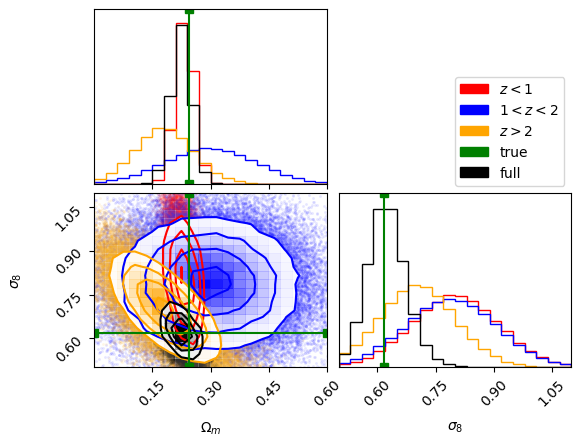

[0.1406 0.9574]
3125/3125 [==============================] - 14s 5ms/step


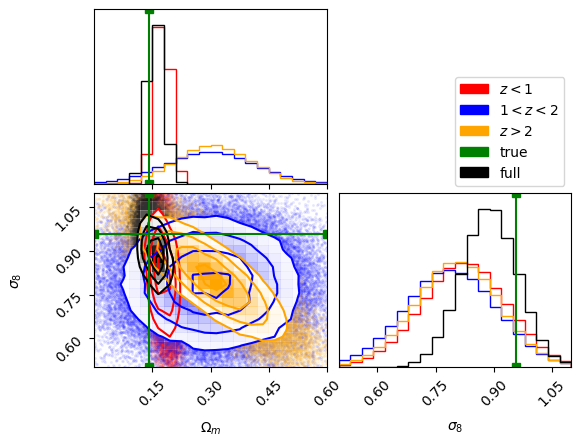

[0.211  0.8598]
3125/3125 [==============================] - 14s 5ms/step


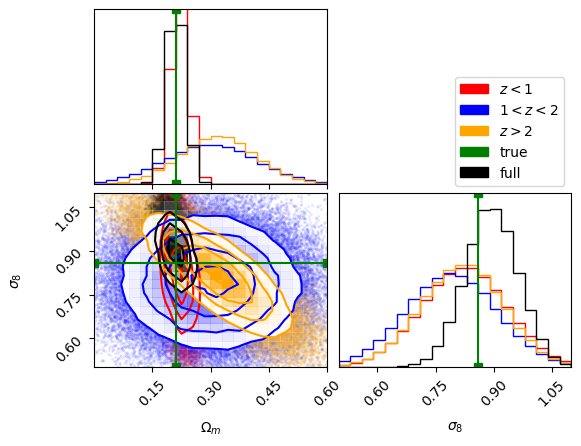

[0.3346 0.7862]
3125/3125 [==============================] - 14s 4ms/step


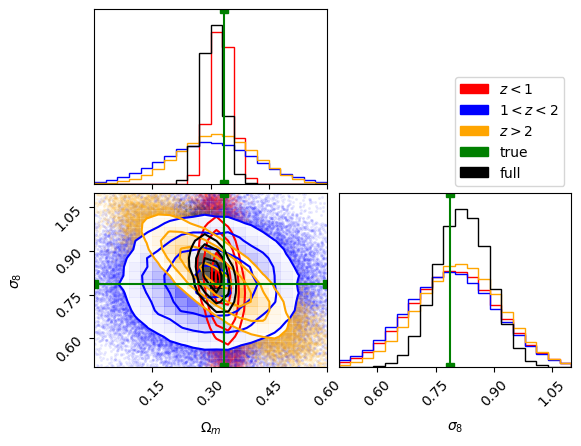

[0.3346 0.7862]
3125/3125 [==============================] - 14s 5ms/step


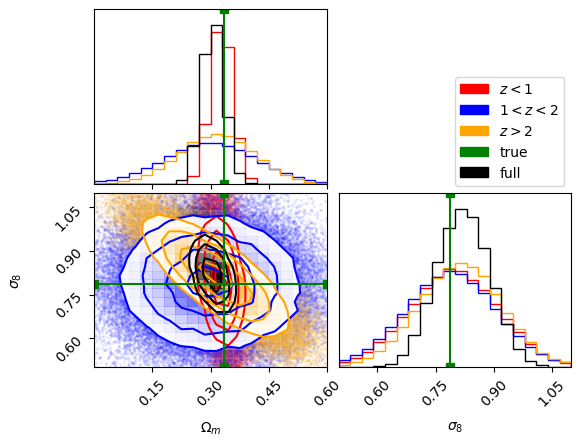

In [65]:
for i in range(5):
    index = np.random.randint(len(test_y))
    print(test_y[index, :2])

    n_pred = 100000
    fig = plt.figure()

    for ind, (model, text_x, color) in enumerate(zip([model_zless1, model_z_1_2, model_zover2, full_model], \
                    [test_x_zless1, test_x_z_1_2, test_x_zover2, test_x], ["red", "blue", "orange", "black"])):
        predictions = model.predict(np.repeat(text_x[index][None, :, :], n_pred, axis=0))[:, :2]
        corner.corner(predictions, labels=[r"$\Omega_m$", r"$\sigma_8$"], fig=fig, color=color, range=[(0, 0.6), (0.5, 1.1)])

    corner.overplot_lines(fig, test_y[index, :2], marker="s", color="green")
    plt.legend(handles=[mpatches.Patch(color='red', label=r'$z<1$'), mpatches.Patch(color='blue', label=r'$1<z<2$'),
                       mpatches.Patch(color='orange', label=r'$z>2$'), mpatches.Patch(color='green', label=r'true'),
                       mpatches.Patch(color='black', label=r'full')], bbox_to_anchor=(0., 1.0, 1., .0), loc=4)
    plt.show()
    plt.close()

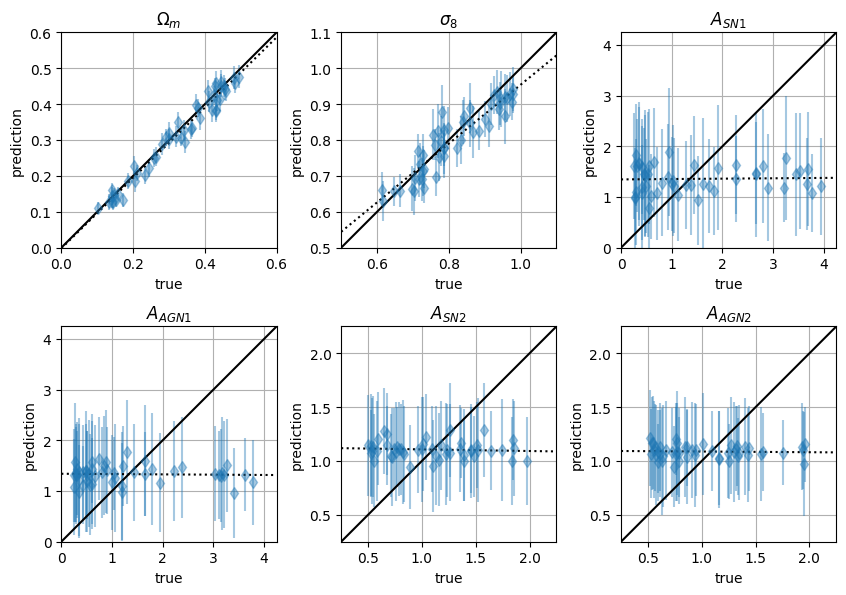

In [49]:
model = full_model

plot_x, plot_y = test_x, test_y

n_pred = 50
predictions = np.empty((n_pred, *plot_y.shape))
for i in range(n_pred):
    predictions[i] = model.predict(plot_x, verbose=0)
predictions_best = np.nanmean(predictions, axis=0)
predictions_std = np.nanstd(predictions, axis=0)

upp_lims = [0.6, 1.1,4.25,4.25,2.25, 2.25]
low_lims = [0, 0.5, 0, 0, 0.25, 0.25]
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(plot_y[:, ind], predictions_best[:, ind], 1))
    ax.errorbar(plot_y[:, ind], predictions_best[:, ind],  predictions_std[:, ind], marker="d", ls='none', alpha=0.4)
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    ax.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    ax.set_xlim([low_lim, upp_lim])
    ax.set_ylim([low_lim, upp_lim])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(label)
    ax.grid()
plt.show()
plt.close()